In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA = ROOT / "data" / "creditcard.csv"
sys.path.append(str(ROOT))

import pandas as pd
from src.split import load_splits, xy

In [2]:
df = pd.read_csv("../data/creditcard.csv")
print(df.shape, df.isna().sum().sum())
print(df["Class"].value_counts())
print(f"Fraud rate: {df['Class'].mean():.4%}")
df.groupby("Class")["Amount"].describe()

(284807, 31) 0
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727%


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [3]:
train, val, test = load_splits("../data/creditcard.csv")
for name, d in zip(["train", "val", "test"], [train, val, test]):
    print(f"{name:5} rows={len(d):6} fraud={int(d['Class'].sum()):4} "
          f"rate={d['Class'].mean():.4%} hours={d['Time'].min()/3600:.1f}-{d['Time'].max()/3600:.1f}")

train rows=199364 fraud= 384 rate=0.1926% hours=0.0-36.9
val   rows= 42721 fraud=  56 rate=0.1311% hours=36.9-42.0
test  rows= 42722 fraud=  52 rate=0.1217% hours=42.0-48.0


In [4]:
from src.features import prepare
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_tr, y_tr = prepare(train)
X_val, y_val = prepare(val)

lr = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=1000))
lr.fit(X_tr, y_tr)
p_val = lr.predict_proba(X_val)[:, 1]
print("trained on", X_tr.shape)

trained on (199364, 29)


In [5]:
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_score, recall_score, confusion_matrix)

print("Random-guess PR-AUC (= fraud rate):", round(y_val.mean(), 4))
print("PR-AUC :", round(average_precision_score(y_val, p_val), 4))
print("ROC-AUC:", round(roc_auc_score(y_val, p_val), 4))

pred = p_val >= 0.5
print("precision@0.5:", round(precision_score(y_val, pred), 4))
print("recall@0.5   :", round(recall_score(y_val, pred), 4))
print(confusion_matrix(y_val, pred))

Random-guess PR-AUC (= fraud rate): 0.0013
PR-AUC : 0.8193
ROC-AUC: 0.981
precision@0.5: 0.0379
recall@0.5   : 0.9286
[[41344  1321]
 [    4    52]]


In [6]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=2,
    class_weight="balanced_subsample", n_jobs=-1, random_state=42,
).fit(X_tr, y_tr)

spw = (y_tr == 0).sum() / (y_tr == 1).sum()   # negatives per positive
xgb = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    scale_pos_weight=spw, tree_method="hist",
    eval_metric="aucpr", random_state=42, n_jobs=-1,
).fit(X_tr, y_tr)

p_rf = rf.predict_proba(X_val)[:, 1]
p_xgb = xgb.predict_proba(X_val)[:, 1]
print("trained both")

trained both


In [7]:
import numpy as np

# soft voting = average the fraud probabilities
p_ens = (p_val + p_rf + p_xgb) / 3

results = {"LogReg": p_val, "RandomForest": p_rf, "XGBoost": p_xgb, "Ensemble": p_ens}
for name, p in results.items():
    print(f"{name:13} PR-AUC={average_precision_score(y_val, p):.4f}  ROC-AUC={roc_auc_score(y_val, p):.4f}")

LogReg        PR-AUC=0.8193  ROC-AUC=0.9810
RandomForest  PR-AUC=0.8789  ROC-AUC=0.9706
XGBoost       PR-AUC=0.8470  ROC-AUC=0.9911
Ensemble      PR-AUC=0.8691  ROC-AUC=0.9812


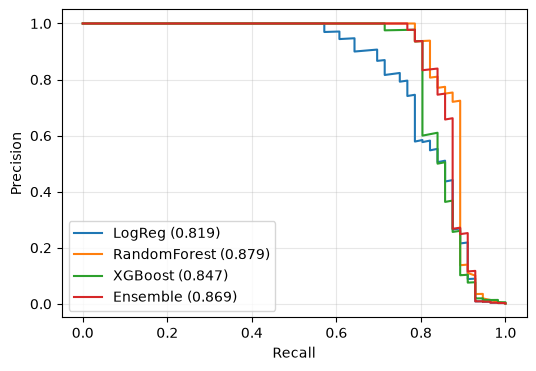

In [8]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for name, p in results.items():
    pr, rc, _ = precision_recall_curve(y_val, p)
    ax.plot(rc, pr, label=f"{name} ({average_precision_score(y_val, p):.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [9]:
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    tn, fp, fn, tp = confusion_matrix(y_val, p_ens >= t).ravel()
    rows.append(dict(threshold=t, caught=tp, missed=fn, false_alarms=fp,
                     precision=round(tp / (tp + fp), 3) if tp + fp else 0,
                     recall=round(tp / (tp + fn), 3)))
pd.DataFrame(rows)

,threshold,caught,missed,false_alarms,precision,recall
0,0.3,51,5,224,0.185,0.911
1,0.4,47,9,11,0.810,0.839
2,0.5,45,11,6,0.882,0.804
3,0.6,44,12,2,0.957,0.786
4,0.7,44,12,1,0.978,0.786
5,0.8,41,15,0,1.000,0.732
6,0.9,36,20,0,1.000,0.643


In [10]:
prec, rec, thr = precision_recall_curve(y_val, p_ens)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best = f1[:-1].argmax()
THRESHOLD = float(thr[best])
print(f"threshold={THRESHOLD:.3f}  precision={prec[best]:.3f}  recall={rec[best]:.3f}  F1={f1[best]:.3f}")

threshold=0.723  precision=0.978  recall=0.786  F1=0.871


In [11]:
%%writefile ../src/ensemble.py
def ensemble_proba(models, X):
    """Soft voting: average the fraud probability of each model."""
    return sum(m.predict_proba(X)[:, 1] for m in models) / len(models)

Overwriting ../src/ensemble.py


In [12]:
import joblib, numpy as np
from src.ensemble import ensemble_proba

THRESHOLD = 0.6
models = [lr, rf, xgb]

assert np.allclose(ensemble_proba(models, X_val), p_ens)   # same as Cell 7

joblib.dump(
    {"models": models, "threshold": THRESHOLD, "features": list(X_tr.columns)},
    ROOT / "models" / "ensemble.joblib",
)
print("saved")

saved


In [13]:
X_te, y_te = prepare(test)
p_te = ensemble_proba(models, X_te)
pred_te = p_te >= THRESHOLD
tn, fp, fn, tp = confusion_matrix(y_te, pred_te).ravel()

print(f"PR-AUC   : {average_precision_score(y_te, p_te):.4f}  (random-guess = {y_te.mean():.4f})")
print(f"precision: {precision_score(y_te, pred_te):.3f}")
print(f"recall   : {recall_score(y_te, pred_te):.3f}")
print(f"caught={tp} missed={fn} false_alarms={fp}")

PR-AUC   : 0.7690  (random-guess = 0.0012)
precision: 0.765
recall   : 0.750
caught=39 missed=13 false_alarms=12


In [14]:
import shap

explainer = shap.TreeExplainer(xgb)

# all validation frauds plus a random sample of normal transactions
X_s = pd.concat([X_val[y_val == 1], X_val[y_val == 0].sample(2000, random_state=0)])
sv = explainer(X_s)
print(sv.values.shape)

(2056, 29)


/Users/dev/fraud-detection/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


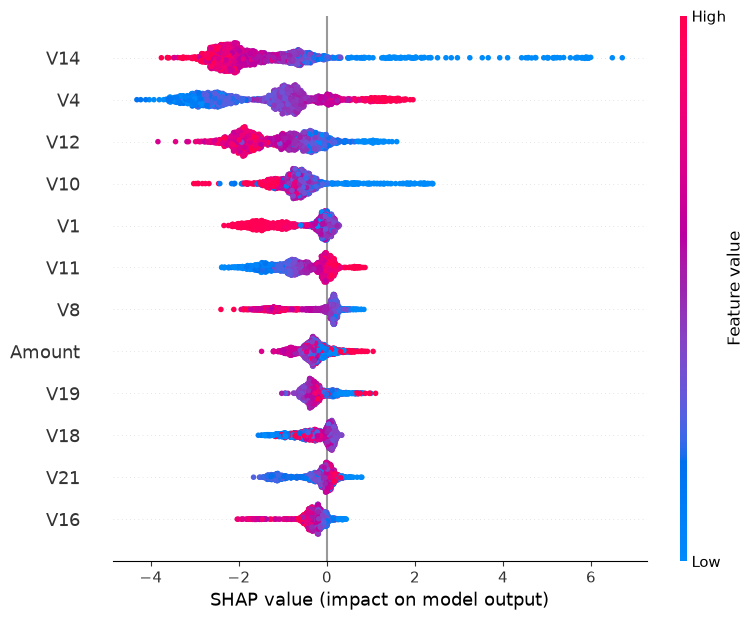

In [15]:
shap.summary_plot(sv.values, X_s, max_display=12)

true class: 1 | XGBoost fraud probability: 0.999


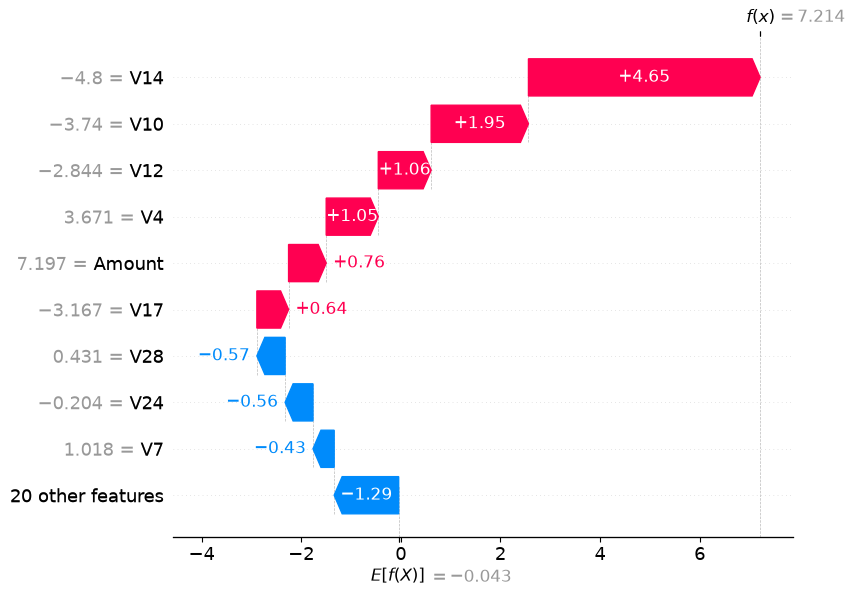

In [16]:
fraud_idx = np.where(y_val.loc[X_s.index].values == 1)[0]
i = fraud_idx[0]
print("true class:", y_val.loc[X_s.index].iloc[i], "| XGBoost fraud probability:", round(float(xgb.predict_proba(X_s.iloc[[i]])[0, 1]), 3))
shap.plots.waterfall(sv[i])

In [17]:
%%writefile ../src/features.py
import numpy as np
from src.split import xy

def to_features(X):
    """Raw transaction columns -> model features. Used in training AND the API."""
    X = X.drop(columns=["Time", "Class"], errors="ignore").copy()
    X["Amount"] = np.log1p(X["Amount"])
    return X

def prepare(d):
    X, y = xy(d)
    return to_features(X), y

Overwriting ../src/features.py


In [18]:
%%writefile ../src/api.py
from pathlib import Path

import joblib
import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

from src.ensemble import ensemble_proba
from src.features import to_features

ART = joblib.load(Path(__file__).resolve().parent.parent / "models" / "ensemble.joblib")
app = FastAPI(title="Fraud Detection API")


class Transaction(BaseModel):
    transaction_id: str
    features: dict[str, float]  # V1..V28 and Amount (Time is ignored)


@app.get("/health")
def health():
    return {"status": "ok", "threshold": ART["threshold"]}


@app.post("/predict")
def predict(t: Transaction):
    X = to_features(pd.DataFrame([t.features]))
    missing = [c for c in ART["features"] if c not in X.columns]
    if missing:
        raise HTTPException(status_code=422, detail=f"missing features: {missing}")
    p = float(ensemble_proba(ART["models"], X[ART["features"]])[0])
    return {
        "transaction_id": t.transaction_id,
        "fraud_probability": round(p, 4),
        "is_fraud": p >= ART["threshold"],
        "threshold": ART["threshold"],
    }

Overwriting ../src/api.py


In [19]:
import json

def payload(row, tid):
    return {"transaction_id": tid,
            "features": {k: float(v) for k, v in row.items() if k != "Class"}}

raw = val.reset_index(drop=True)
(ROOT / "tests").mkdir(exist_ok=True)
json.dump(payload(raw[raw["Class"] == 1].iloc[0], "TXN_FRAUD"), open(ROOT / "tests" / "sample_fraud.json", "w"))
json.dump(payload(raw[raw["Class"] == 0].iloc[0], "TXN_NORMAL"), open(ROOT / "tests" / "sample_normal.json", "w"))
print("written")

written


In [20]:
(ROOT / "docs").mkdir(exist_ok=True)
plt.figure()
shap.summary_plot(sv.values, X_s, max_display=12, show=False)
plt.savefig(ROOT / "docs" / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.close()
print("saved")

saved
